<a href="https://colab.research.google.com/github/Chaitanya15-ai/ALFIDO/blob/main/ALFIDO_TASK_2(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123



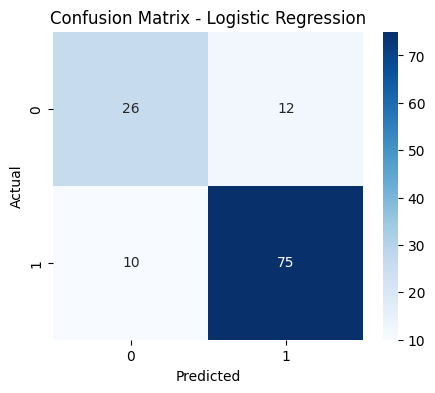

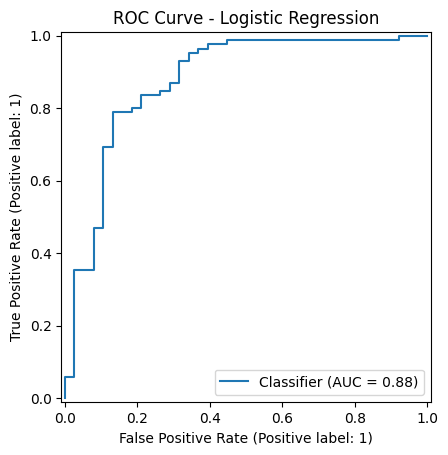


Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.71      0.63        38
           1       0.85      0.75      0.80        85

    accuracy                           0.74       123
   macro avg       0.71      0.73      0.71       123
weighted avg       0.76      0.74      0.75       123



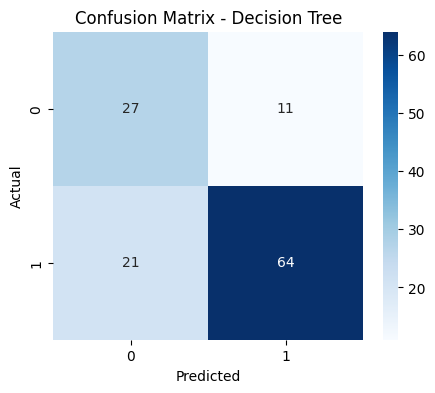

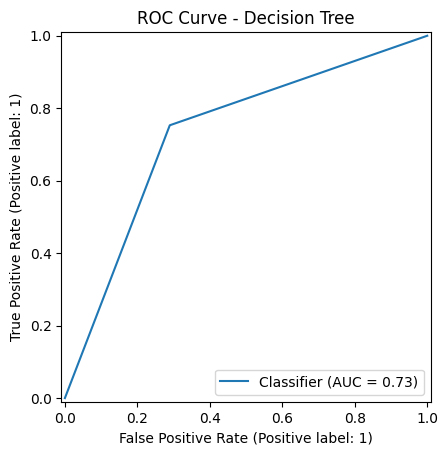


Random Forest
              precision    recall  f1-score   support

           0       0.70      0.61      0.65        38
           1       0.83      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.74      0.75       123
weighted avg       0.79      0.80      0.79       123



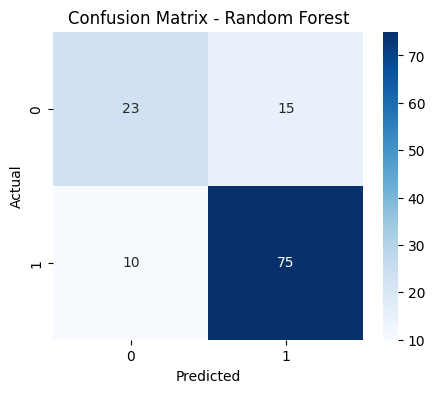

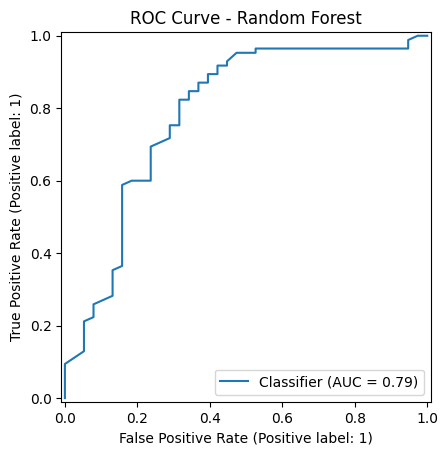


Model Comparison
                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.862069  0.882353  0.872093  0.875851
2        Random Forest   0.833333  0.882353  0.857143  0.787616
1        Decision Tree   0.853333  0.752941  0.800000  0.731734


<Figure size 1000x500 with 0 Axes>

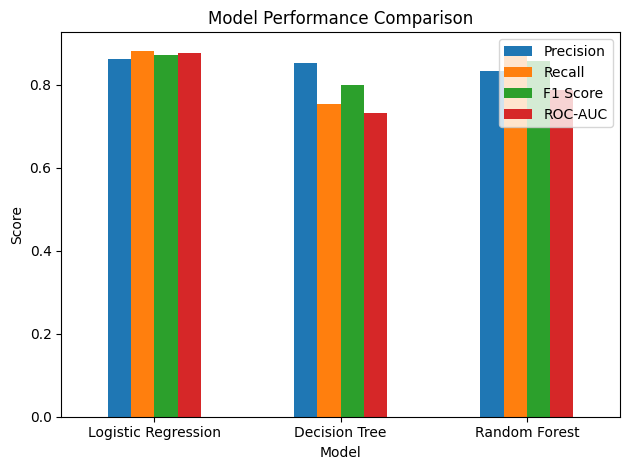


Top 15 Important Features
                         Feature  Importance
0           num__ApplicantIncome    0.184777
4            num__Credit_History    0.179475
2                num__LoanAmount    0.159223
1         num__CoapplicantIncome    0.101629
18  cat__Property_Area_Semiurban    0.043228
3          num__Loan_Amount_Term    0.033586
17      cat__Property_Area_Rural    0.032700
9              cat__Dependents_0    0.028355
10             cat__Dependents_1    0.026332
19      cat__Property_Area_Urban    0.022801
13       cat__Education_Graduate    0.020881
14   cat__Education_Not Graduate    0.020766
8               cat__Married_Yes    0.020593
5             cat__Gender_Female    0.018894
7                cat__Married_No    0.018854


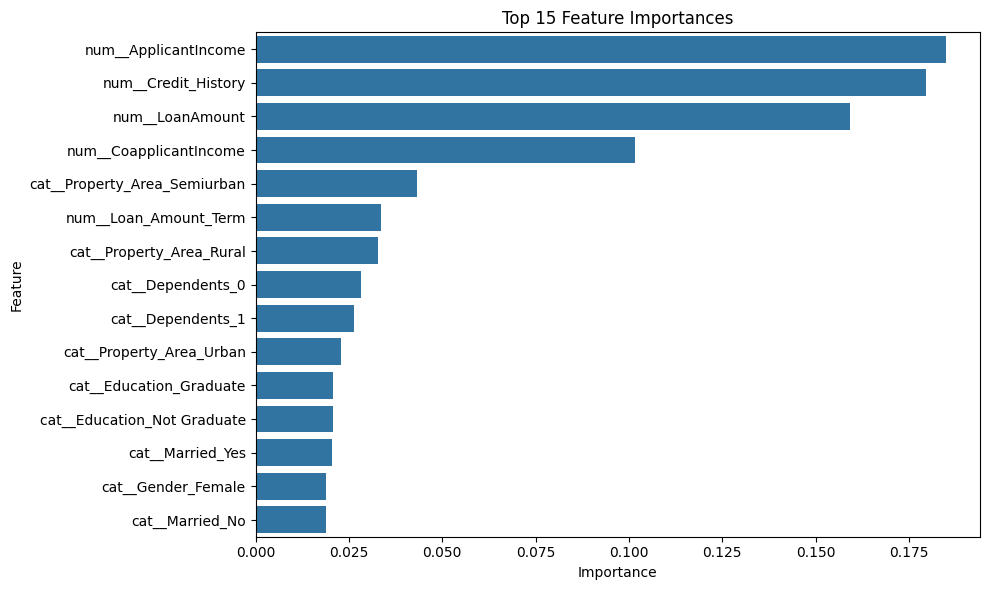

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv("loan_prediction.csv")

df.drop("Loan_ID", axis=1, inplace=True)

df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )
    plt.title(f"ROC Curve - {name}")
    plt.show()

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\nModel Comparison")
print(results_df.sort_values("ROC-AUC", ascending=False))

plt.figure(figsize=(10, 5))
results_df.set_index("Model").plot(
    kind="bar"
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rf_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 Important Features")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()